In [17]:
import pandas as pd
df=pd.read_csv("ads group.csv")

In [3]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/02/2016,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/03/2017,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,4/03/2017,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/06/2016,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ads group.csv')
print(df.shape)

(13580, 21)


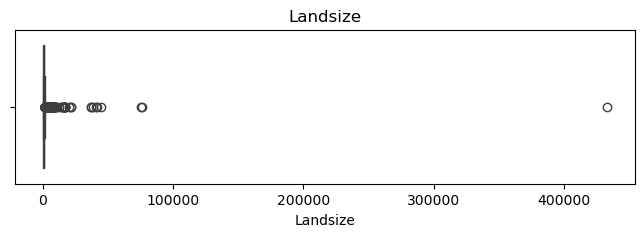

In [19]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='Landsize')
plt.title('Landsize')
plt.show()

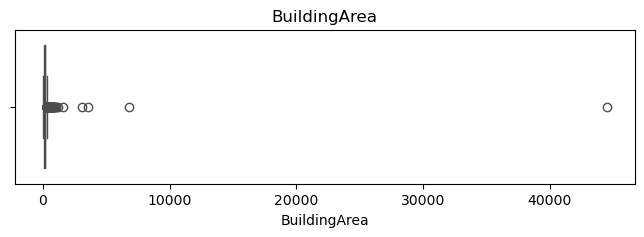

In [20]:
# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='BuildingArea', color='orange')
plt.title('BuildingArea')
plt.show()

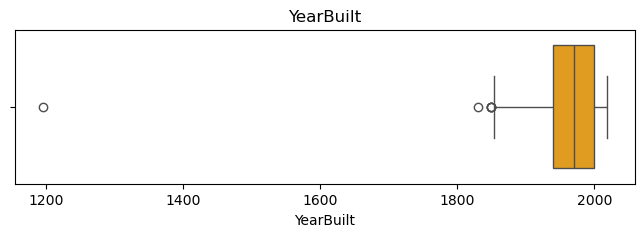

In [21]:
# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='YearBuilt', color='orange')
plt.title('YearBuilt')
plt.show()

In [22]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [23]:
# Assume missing car spaces mean 0 parking spots available
df['Car'] = df['Car'].fillna(0)

# checks if there is still missing values
car = df['Car'].count()
print(car)

13580


In [24]:
# Drops rows where BuildingArea and YearBuilt are missing
df_clean = df.dropna(subset=['BuildingArea', 'YearBuilt'])

# Remove impossible 0 square metre entries
df_clean = df_clean[df_clean['Landsize'] > 0]
df_clean = df_clean[df_clean['BuildingArea'] > 0]

# Fix the Date data type mismatch so it plots chronologically
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y', errors='coerce')

In [25]:
print("Check")
print("Number of properties with 0 Landsize left:", (df_clean['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df_clean['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df_clean['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df_clean))

Check
Number of properties with 0 Landsize left: 0
Number of properties with 0 Building area left: 0
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 5826


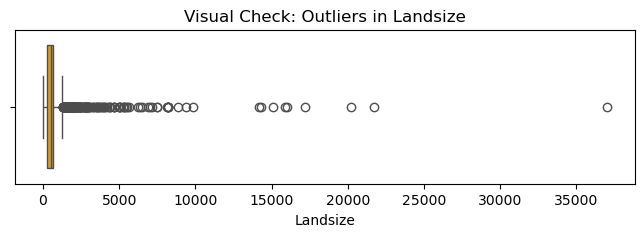

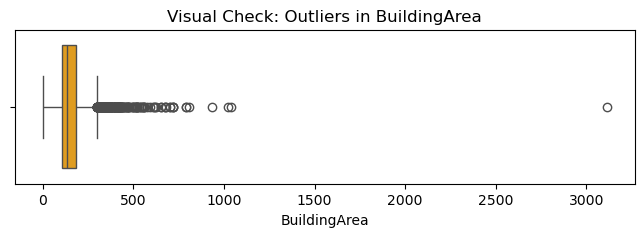

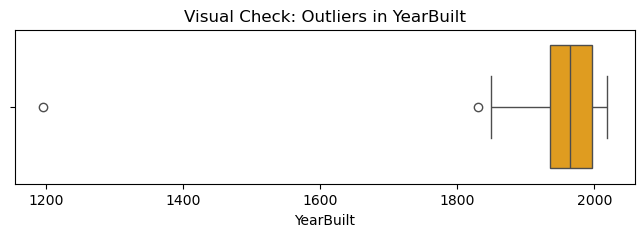

In [26]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [27]:
# 1. Reset df_clean back to a fresh copy of your raw data
df_clean = df.copy()

In [28]:
# --- Clean Landsize ---
Q1_land = df_clean['Landsize'].quantile(0.25)
Q3_land = df_clean['Landsize'].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df_clean = df_clean[(df_clean['Landsize'] >= lower_land) & (df_clean['Landsize'] <= upper_land)]

# --- Clean BuildingArea ---
Q1_build = df_clean['BuildingArea'].quantile(0.25)
Q3_build = df_clean['BuildingArea'].quantile(0.75)
IQR_build = Q3_build - Q1_build
lower_build = Q1_build - 1.5 * IQR_build
upper_build = Q3_build + 1.5 * IQR_build
df_clean = df_clean[(df_clean['BuildingArea'] >= lower_build) & (df_clean['BuildingArea'] <= upper_build)]

# --- Clean YearBuilt ---
Q1_year = df_clean['YearBuilt'].quantile(0.25)
Q3_year = df_clean['YearBuilt'].quantile(0.75)
IQR_year = Q3_year - Q1_year
lower_year = Q1_year - 1.5 * IQR_year
upper_year = Q3_year + 1.5 * IQR_year
df_clean = df_clean[(df_clean['YearBuilt'] >= lower_year) & (df_clean['YearBuilt'] <= upper_year)]

print("Data successfully cleaned! Total rows remaining:", len(df_clean))

Data successfully cleaned! Total rows remaining: 6377


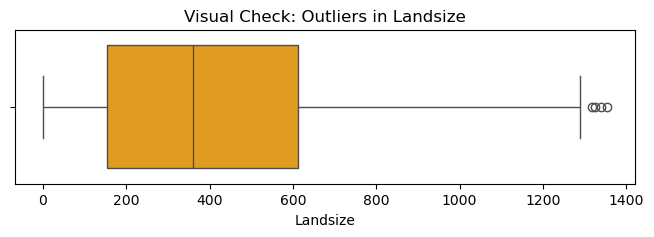

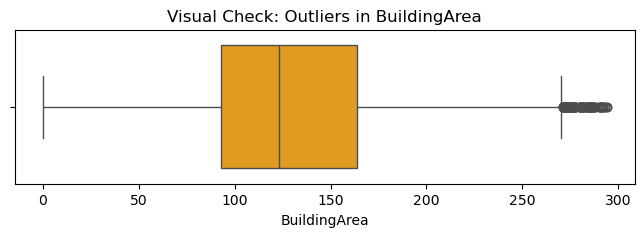

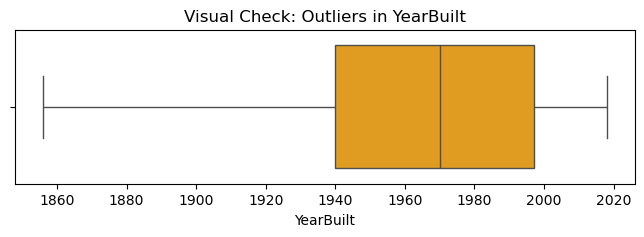

In [29]:

# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [30]:
# 1. Reset df_clean back to a fresh copy of your raw data
df_clean = df.copy()

In [31]:
# 1. Remove the last remaining Landsize dots above the whisker
df_clean = df_clean[df_clean['Landsize'] <= 1280]

# 2. Remove the last remaining BuildingArea dots above the whisker
df_clean = df_clean[df_clean['BuildingArea'] <= 260]

# 3. Remove the single leftover YearBuilt dot below the whisker
df_clean = df_clean[df_clean['YearBuilt'] >= 1860]

print("Final manual trim complete! Remaining rows:", len(df_clean))

Final manual trim complete! Remaining rows: 6193


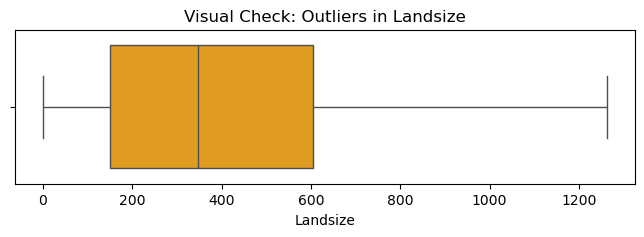

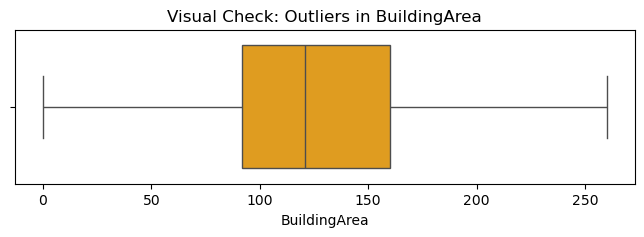

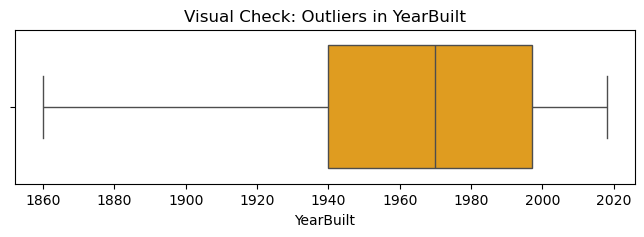

In [32]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

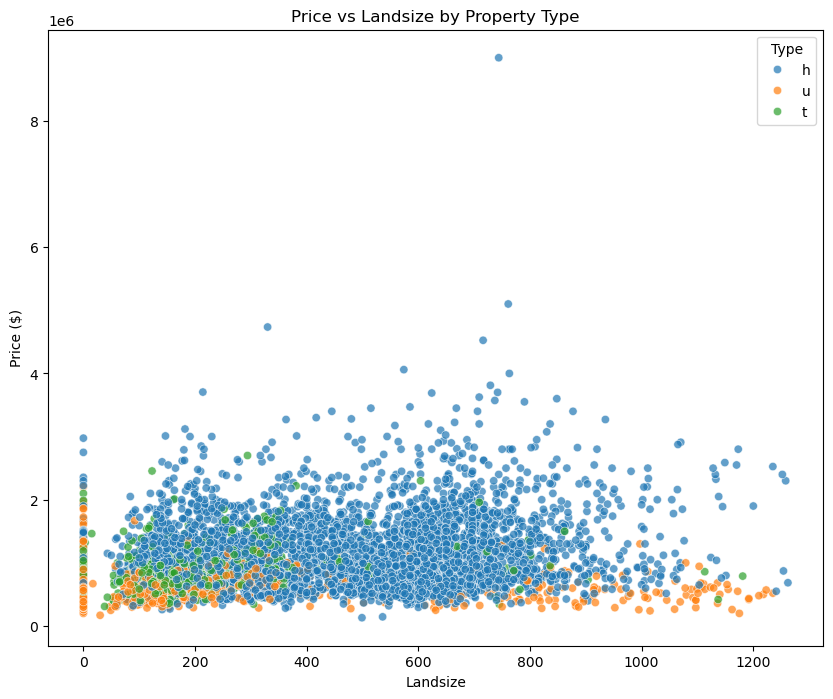

In [41]:
#old
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

sns.scatterplot(data=df_clean,
                x='Landsize',
                y='Price',
                hue='Type',
                alpha=0.7)

plt.title('Price vs Landsize by Property Type')
plt.xlabel('Landsize')
plt.ylabel('Price ($)')
plt.show()

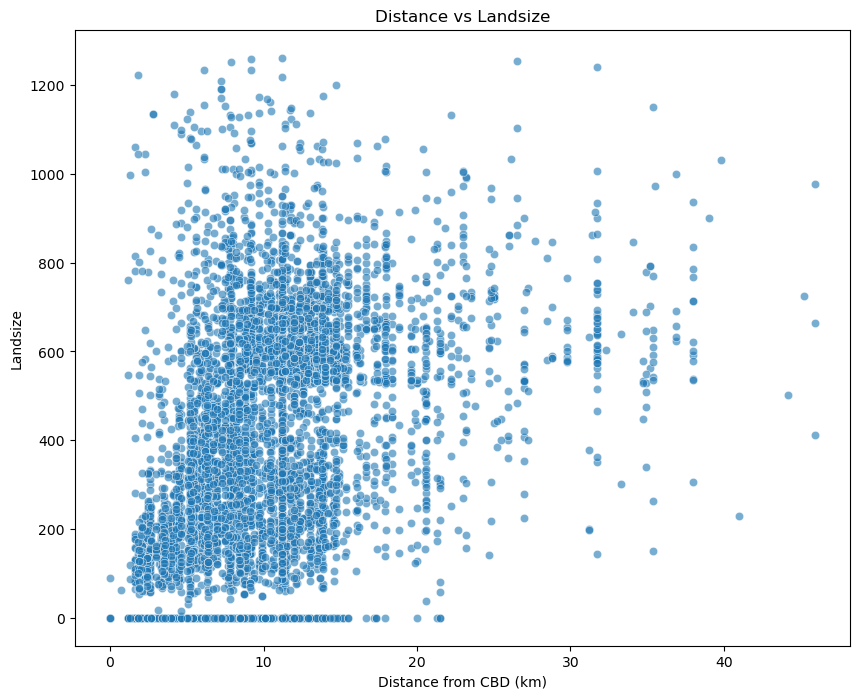

In [40]:
#old
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_clean, x='Distance', y='Landsize', alpha=0.6)

plt.title('Distance vs Landsize')
plt.xlabel('Distance from CBD (km)')
plt.ylabel('Landsize')

plt.show()

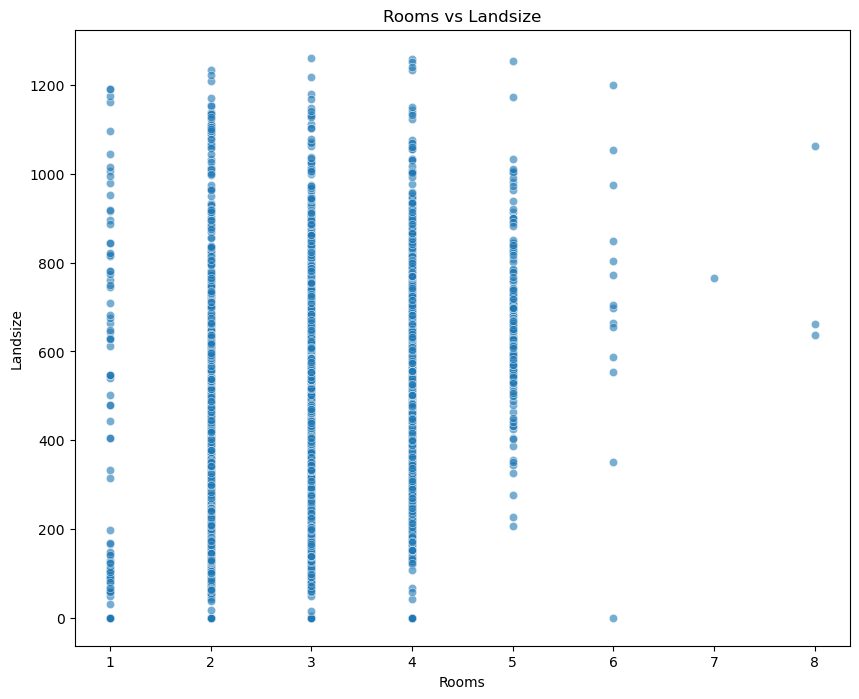

In [42]:
#old
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_clean, x='Rooms', y='Landsize', alpha=0.6)

plt.title('Rooms vs Landsize')
plt.xlabel('Rooms')
plt.ylabel('Landsize')

plt.show()

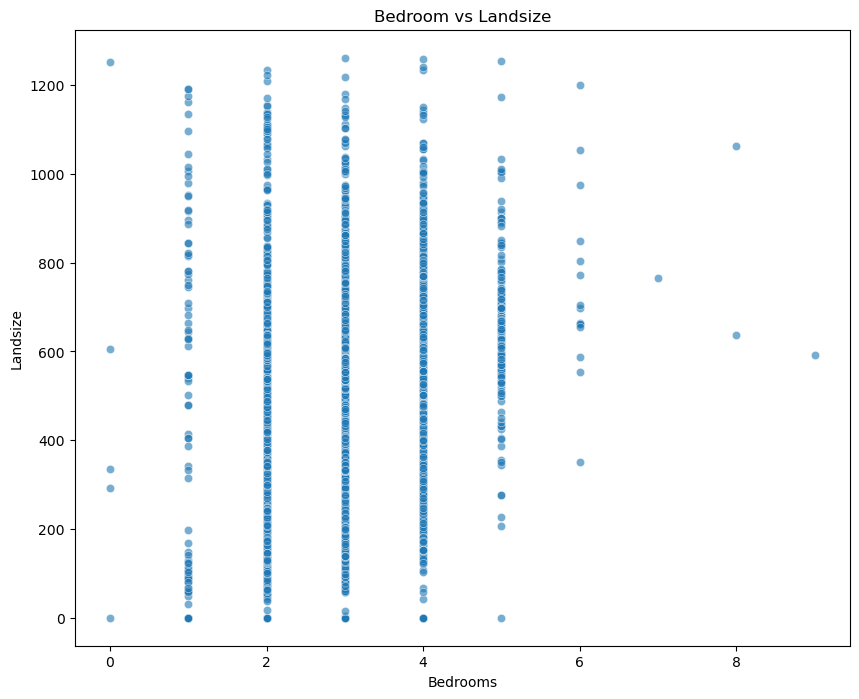

In [43]:
#old
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_clean, x='Bedroom2', y='Landsize', alpha=0.6)

plt.title('Bedroom vs Landsize')
plt.xlabel('Bedrooms')
plt.ylabel('Landsize')

plt.show()

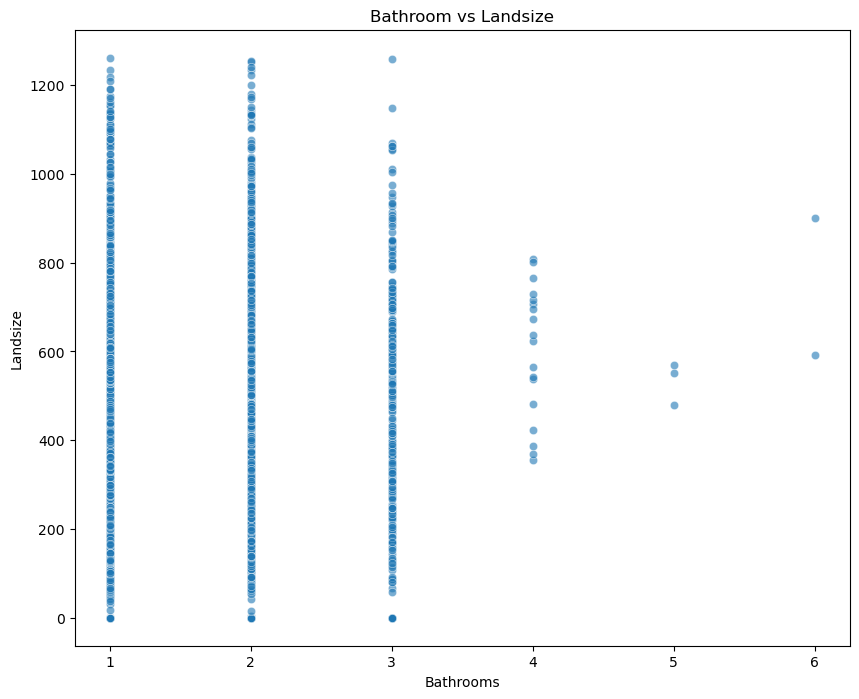

In [44]:
#old
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_clean, x='Bathroom', y='Landsize', alpha=0.6)

plt.title('Bathroom vs Landsize')
plt.xlabel('Bathrooms')
plt.ylabel('Landsize')

plt.show()

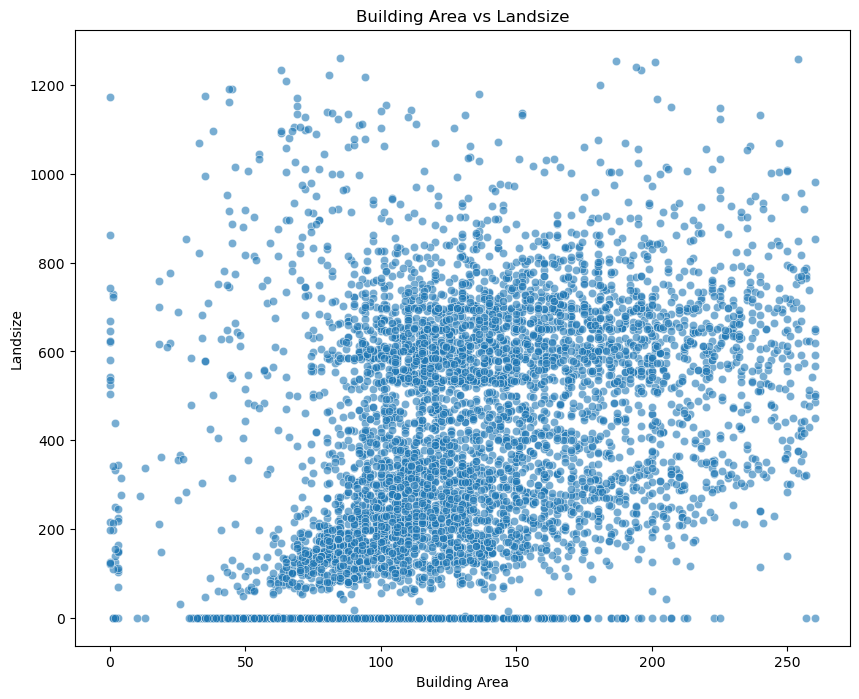

In [45]:
#old
plt.figure(figsize=(10,8))
sns.scatterplot(data=df_clean, x='BuildingArea', y='Landsize', alpha=0.6)

plt.title('Building Area vs Landsize')
plt.xlabel('Building Area')
plt.ylabel('Landsize')

plt.show()

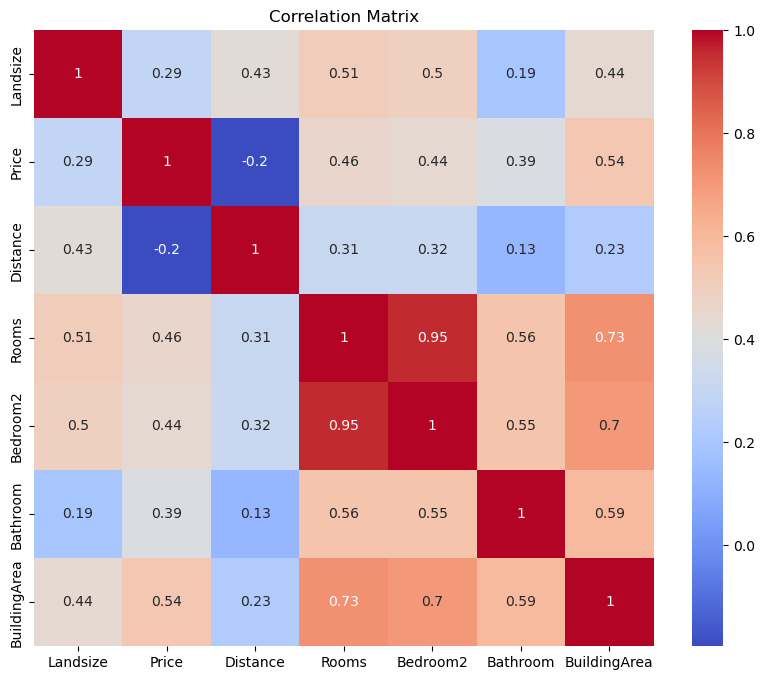

In [46]:
#
corr = df_clean[['Landsize','Price','Distance','Rooms',
           'Bedroom2','Bathroom','BuildingArea']].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title('Correlation Matrix')
plt.show()